#### A. Conduct an Exploratory Data Analysis (EDA) on the dataset. Highlight the main insights and any irregularities you find, and address those anomalies appropriately!

In [242]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
pd.set_option("display.max_columns", None)

In [243]:
df = pd.read_csv("song_recomendation_A.csv")

In [244]:
df.head(5)

,Track URI,Track Name,Artist Name(s),Album Name,Album Release Date,Popularity,Artist Genres,Danceability,Energy,Key,Loudness,Mode,Speechiness,Acousticness,Instrumentalness,Liveness,Valence,Tempo,Time Signature
0,spotify:track:38tpcZDofjtDNunMm5w1EU,If I Could Change Your Mind,HAIM,Days Are Gone (Deluxe Edition),2013-01-01,53,"indietronica,metropopolis",0.671,0.852,2.0,-5.557,0.0,0.0425,0.01840,0.000099,0.0841,0.737,125.043,4.0
1,spotify:track:60lJebAiPbIrnLeGev6kHX,If I Ain't Got You,Alicia Keys,The Diary Of Alicia Keys,2003,0,"neo soul,pop,r&b",0.589,0.449,7.0,-9.153,1.0,0.1050,0.60700,0.000022,0.1000,0.159,118.351,3.0
2,spotify:track:1dbt3sOwRmUOLfQZSpSz9O,Truly,Lionel Richie,Lionel Richie (Expanded Edition),1982,0,soft rock,0.366,0.238,1.0,-13.853,1.0,0.0381,0.64600,0.000010,0.0876,0.131,68.362,4.0
3,spotify:track:50PeqUz1BjMw9ayNTk5O4d,I've Been Thinking About You,Londonbeat,Best! The Singles 16 Tracks,1995-11-20,69,"eurodance,hip house",0.678,0.659,11.0,-12.695,0.0,0.0396,0.02360,0.001920,0.0744,0.899,113.542,4.0
4,spotify:track:111P8I22TrLyxQm7Jcwdoy,Kung Fu Fighting,"Bus Stop, Carl Douglas",The Soul of the Kung Fu Fighter,1972-02-13,0,NaN,0.737,0.855,11.0,-10.319,0.0,0.0646,0.00475,0.000017,0.1630,0.583,116.023,4.0


Only on the first preliminary check and I've discover a lot of anomalies already:
- Uninformative columns, such as **Track URl**, **Track Name**, **Artist Name(s)**, and **Album Name**, are just identifiers for each songs and where they came from. Since I want to build a recommendation system that focuses only on the content and not how similar the names of each songs are, I will definitely won't use these as predictors.
- Multiple values inside **Artist Genres** which cannot be directly encoded, but needs to be separated first into binary indicators of their own.
- There appears to be missing values inside of **Artist Genres** labeled by NaN.
- Negative **loudness** in decibles seems unintuitive but it actually indicates that a measured value is lower than the chosen reference level, so it is possible for it to be negative.

In [245]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 19 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Track URI           5000 non-null   object 
 1   Track Name          4999 non-null   object 
 2   Artist Name(s)      4999 non-null   object 
 3   Album Name          4999 non-null   object 
 4   Album Release Date  5000 non-null   object 
 5   Popularity          5000 non-null   int64  
 6   Artist Genres       4705 non-null   object 
 7   Danceability        5000 non-null   float64
 8   Energy              5000 non-null   float64
 9   Key                 5000 non-null   float64
 10  Loudness            5000 non-null   float64
 11  Mode                5000 non-null   float64
 12  Speechiness         5000 non-null   float64
 13  Acousticness        4850 non-null   float64
 14  Instrumentalness    5000 non-null   float64
 15  Liveness            5000 non-null   float64
 16  Valenc

There are a hefty amount of missing values on some columns, but the real problem lies on NULLs in Track Name, Artist Name(s), and Album Name because those are the mandatory things to recommend songs to users. Without them, users would get a song that doesn't exist recommended to them, so it would be better to just drop the rows containing missing values directly. Also, the Album Release Date hasn't been turned into date type data type so I will type cast that.

In [246]:
df = df.dropna(subset=['Track Name', 'Artist Name(s)', 'Album Name'])

In [247]:
df['Album Release Year'] = df['Album Release Date'].astype(str).str.extract(r'(\d{4})').astype(int)
df = df.drop(columns='Album Release Date')

In [248]:
df.head(5)

,Track URI,Track Name,Artist Name(s),Album Name,Popularity,Artist Genres,Danceability,Energy,Key,Loudness,Mode,Speechiness,Acousticness,Instrumentalness,Liveness,Valence,Tempo,Time Signature,Album Release Year
0,spotify:track:38tpcZDofjtDNunMm5w1EU,If I Could Change Your Mind,HAIM,Days Are Gone (Deluxe Edition),53,"indietronica,metropopolis",0.671,0.852,2.0,-5.557,0.0,0.0425,0.01840,0.000099,0.0841,0.737,125.043,4.0,2013
1,spotify:track:60lJebAiPbIrnLeGev6kHX,If I Ain't Got You,Alicia Keys,The Diary Of Alicia Keys,0,"neo soul,pop,r&b",0.589,0.449,7.0,-9.153,1.0,0.1050,0.60700,0.000022,0.1000,0.159,118.351,3.0,2003
2,spotify:track:1dbt3sOwRmUOLfQZSpSz9O,Truly,Lionel Richie,Lionel Richie (Expanded Edition),0,soft rock,0.366,0.238,1.0,-13.853,1.0,0.0381,0.64600,0.000010,0.0876,0.131,68.362,4.0,1982
3,spotify:track:50PeqUz1BjMw9ayNTk5O4d,I've Been Thinking About You,Londonbeat,Best! The Singles 16 Tracks,69,"eurodance,hip house",0.678,0.659,11.0,-12.695,0.0,0.0396,0.02360,0.001920,0.0744,0.899,113.542,4.0,1995
4,spotify:track:111P8I22TrLyxQm7Jcwdoy,Kung Fu Fighting,"Bus Stop, Carl Douglas",The Soul of the Kung Fu Fighter,0,NaN,0.737,0.855,11.0,-10.319,0.0,0.0646,0.00475,0.000017,0.1630,0.583,116.023,4.0,1972


In [249]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4999 entries, 0 to 4999
Data columns (total 19 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Track URI           4999 non-null   object 
 1   Track Name          4999 non-null   object 
 2   Artist Name(s)      4999 non-null   object 
 3   Album Name          4999 non-null   object 
 4   Popularity          4999 non-null   int64  
 5   Artist Genres       4705 non-null   object 
 6   Danceability        4999 non-null   float64
 7   Energy              4999 non-null   float64
 8   Key                 4999 non-null   float64
 9   Loudness            4999 non-null   float64
 10  Mode                4999 non-null   float64
 11  Speechiness         4999 non-null   float64
 12  Acousticness        4849 non-null   float64
 13  Instrumentalness    4999 non-null   float64
 14  Liveness            4999 non-null   float64
 15  Valence             4999 non-null   float64
 16  Tempo      

In [250]:
df.describe(include='object')

,Track URI,Track Name,Artist Name(s),Album Name,Artist Genres
count,4999,4999,4999,4999,4705
unique,4987,4510,2653,3886,1902
top,spotify:track:7hQJA50XrCWABAu5v6QZ4i,One,Elvis Presley,Greatest Hits,"dance pop,pop"
freq,3,6,27,51,121


No problem for this one.

In [251]:
df.describe(exclude='object')

,Popularity,Danceability,Energy,Key,Loudness,Mode,Speechiness,Acousticness,Instrumentalness,Liveness,Valence,Tempo,Time Signature,Album Release Year
count,4999.000000,4999.000000,4999.000000,4999.000000,4999.00000,4999.000000,4999.000000,4849.000000,4999.000000,4999.000000,4999.000000,4749.000000,4999.000000,4999.000000
mean,37.194039,0.607779,0.683945,5.189838,-7.28843,0.702741,0.064976,0.208048,0.031169,0.186398,0.587967,121.195912,3.959792,2001.874775
std,29.414521,0.146725,0.190946,3.590672,3.32124,0.457097,0.060146,0.248302,0.128122,0.150543,0.239386,26.328982,0.238760,15.297605
min,0.000000,0.099400,0.020500,0.000000,-23.24200,0.000000,0.021800,0.000003,0.000000,0.012000,0.033400,59.406000,1.000000,1956.000000
25%,0.000000,0.513000,0.564000,2.000000,-9.08000,0.000000,0.033300,0.018400,0.000000,0.089150,0.400000,102.040000,4.000000,1993.000000
50%,41.000000,0.619000,0.710000,5.000000,-6.49200,1.000000,0.043100,0.098200,0.000005,0.127000,0.601000,120.336000,4.000000,2007.000000
75%,63.000000,0.712000,0.836000,8.000000,-4.90550,1.000000,0.068300,0.312000,0.000604,0.247500,0.787000,134.196000,4.000000,2014.000000
max,95.000000,0.988000,0.994000,11.000000,2.76900,1.000000,0.519000,0.991000,0.985000,0.989000,0.995000,217.913000,5.000000,2023.000000


Each and every value looks valid and there's no unexplainable negative values or ridiculously high values.

# Categorical Checks

In [253]:
cat_cols = ['Track URI', 'Track Name', 'Artist Name(s)', 'Album Name', 'Artist Genres']
for c in cat_cols:
    print(f"Distinct categories and its percentage for {c}:")
    print(df[c].value_counts(normalize=True, dropna=True), end='\n\n')

Distinct categories and its percentage for Track URI:
Track URI
spotify:track:7hQJA50XrCWABAu5v6QZ4i    0.0006
spotify:track:1SRkKyJ2JjMZgyDWC30zKv    0.0004
spotify:track:7Dm3dV3WPNdTgxoNY7YFnc    0.0004
spotify:track:6kooDsorCpWVMGc994XjWN    0.0004
spotify:track:2sXp9Qmvc7mRaDBjBgcGGi    0.0004
                                         ...  
spotify:track:2LIh4uzqq9cXMPzzmcToHl    0.0002
spotify:track:3JhwxN5fPtpWh8O4qCBjYO    0.0002
spotify:track:0TwxA1UTqCXyihWqu6PMWh    0.0002
spotify:track:0A4PZuepTcIQVvA5m7R0M1    0.0002
spotify:track:4HaKJH8swiAIRuiU2mgr6f    0.0002
Name: proportion, Length: 4987, dtype: float64

Distinct categories and its percentage for Track Name:
Track Name
One                               0.0012
Last Night                        0.0012
Higher                            0.0010
How Deep Is Your Love             0.0010
Stay                              0.0010
                                   ...  
Cinnamon                          0.0002
STAY (with Justin 

The only problem for the categorical columns is how there are multiple categories inside of Artist Genres, let's split them up into something that we can use!

In [254]:
genre_lists = df['Artist Genres'].dropna().str.split(',')
genre_lists

0                                                                                              [indietronica, metropopolis]
1                                                                                                      [neo soul, pop, r&b]
2                                                                                                               [soft rock]
3                                                                                                    [eurodance, hip house]
5                                                                                      [dance pop, pop, urban contemporary]
                                                               ...                                                         
4994                                                                                 [brill building pop, classic schlager]
4995                                                                                                [la pop, women's music]
4996    

In [255]:
genre_dummies = genre_lists.explode().str.strip().pipe(pd.get_dummies).groupby(level=0).max()
genre_dummies

,a cappella,acid house,acid rock,acoustic cover,acoustic pop,acoustic punk,adelaide punk,adult standards,african rock,afrobeats,afrofuturism,afropop,afroswing,alaska indie,album rock,alt z,alte,alternative country,alternative dance,alternative hip hop,alternative metal,alternative r&b,alternative rock,ambient house,ambient pop,american folk revival,anarcho-punk,anti-folk,antiviral pop,argentine heavy metal,argentine rock,arkansas country,art pop,art punk,art rock,asian american hip hop,athens indie,atl hip hop,atl trap,atlanta bass,auckland indie,aussie emo,aussietronica,austin singer-songwriter,australian alternative pop,australian alternative rock,australian americana,australian children's music,australian comedy,australian country,australian dance,australian electropop,australian hip hop,australian house,australian indie,australian indie folk,australian indie rock,australian indigenous,australian indigenous hip hop,australian pop,australian psych,australian r&b,australian reggae fusion,australian rock,australian singer-songwriter,australian ska,australian talent show,australian trap,australian underground hip hop,austrian pop,azonto,balkan beats,ballroom,banjo,barbadian pop,baroque pop,bass house,battle rap,bboy,beatlesque,bedroom pop,belgian dance,belgian edm,belgian pop,bergen indie,big band,big beat,big room,birmingham metal,black americana,blues,blues rock,boston punk,boston rock,bouncy house,boy band,breakbeat,brill building pop,brit funk,britcore,british alternative rock,british blues,british children's music,british comedy,british folk,british indie rock,british invasion,british soul,britpop,britpop revival,broadway,bronx hip hop,brooklyn drill,brooklyn indie,brostep,bubble trance,bubblegrunge,bubblegum dance,bubblegum pop,bush ballad,c86,cabaret,cali rap,calypso,canadian celtic,canadian contemporary r&b,canadian country,canadian electronic,canadian electropop,canadian folk,canadian hip hop,canadian indie,canadian latin,canadian old school hip hop,canadian pop,canadian pop punk,canadian psychedelic,canadian punk,canadian rock,canadian rockabilly,canadian singer-songwriter,canadian trap,candy pop,canzone napoletana,cartoon,ccm,celtic,celtic rock,chamber pop,chanson,charlottesville indie,chicago bop,chicago indie,chicago rap,chicago soul,chicano rap,children's music,christian alternative rock,christian music,classic australian country,classic canadian rock,classic country pop,classic dubstep,classic garage rock,classic girl group,classic greek pop,classic hardstyle,classic nz pop,classic oklahoma country,classic rock,classic schlager,classic soul,classic soundtrack,classic swedish pop,classic texas country,classic uk pop,classical tenor,colombian pop,comedy,comedy rock,comic,comic metal,complextro,conscious hip hop,contemporary country,contemporary post-bop,contemporary r&b,contemporary vocal jazz,cosmic american,country,country dawn,country gospel,country pop,country road,country rock,cowboy western,crunk,cyberpunk,dance pop,dance rock,dance-punk,dancefloor dnb,dancehall,dancehall queen,danish electronic,danish pop,dansktop,deep adult standards,deep euro house,deep groove house,deep house,deep minimal techno,deep r&b,deep ragga,deep soft rock,deep talent show,deep underground hip hop,detroit hip hop,detroit rock,devon indie,dfw rap,didgeridoo,dirty south rap,disco,disco house,diva house,dixieland,doo-wop,double drumming,downtempo,dream pop,dream trance,drum and bass,dunedin sound,dutch edm,dutch house,dutch pop,dutch prog,dutch rock,early synthpop,east coast hip hop,easy listening,ectofolk,edm,electric blues,electro,electro house,electro jazz,electrofox,electronic rock,electronic trap,electronica,electropop,electropowerpop,emo,emo rap,escape room,etherpop,euphoric hardstyle,eurodance,europop,experimental,experimental pop,experimental rock,experimental vocal,fidget house,filmi,filter house,finnish alternative rock,finnish edm,flute rock,folk,folk rock,folk-pop,freakbeat,freestyle,french hip hop,french indie pop,french 

It doesn't seem viable to convert the genre column into binary indicators since it results to 741 new columns, which highly risks curse of dimensionality that producing extremely sparse high-dimensional vectors that reduce meaningful overlap between items, thereby weakening similarity signals even under cosine similarity. As an alternative, I'll try binary encoding where it balances out the ordinal property from Label Encoding and high dimensionality from One Hot Encoding. It is pretty much One Hot Encoding but in base 2 (binary).

In [256]:
df['genres_list'] = df['Artist Genres'].str.split(',')
df['genres_list']

0                                                                                              [indietronica, metropopolis]
1                                                                                                      [neo soul, pop, r&b]
2                                                                                                               [soft rock]
3                                                                                                    [eurodance, hip house]
4                                                                                                                       NaN
                                                               ...                                                         
4995                                                                                                [la pop, women's music]
4996                                                           [adult standards, easy listening, rock-and-roll, rockabilly]
4997    

In [257]:
df_exploded = df[['genres_list']].explode('genres_list')
df_exploded = df_exploded.rename(columns={'genres_list': 'genre'})
df_exploded

,genre
0,indietronica
0,metropopolis
1,neo soul
1,pop
1,r&b
...,...
4999,pop rap
4999,rap
4999,melodic rap
4999,rap


In [258]:
from category_encoders import BinaryEncoder

be = BinaryEncoder(cols=['genre'])
genre_binary = be.fit_transform(df_exploded[['genre']])
genre_binary

,genre_0,genre_1,genre_2,genre_3,genre_4,genre_5,genre_6,genre_7,genre_8,genre_9
0,0,0,0,0,0,0,0,0,0,1
0,0,0,0,0,0,0,0,0,1,0
1,0,0,0,0,0,0,0,0,1,1
1,0,0,0,0,0,0,0,1,0,0
1,0,0,0,0,0,0,0,1,0,1
...,...,...,...,...,...,...,...,...,...,...
4999,0,0,0,1,1,0,0,0,1,0
4999,0,0,0,1,1,0,0,0,0,0
4999,0,0,1,1,0,1,1,0,0,0
4999,0,0,0,1,1,0,0,0,0,0


In [259]:
genre_binary['song_id'] = df_exploded.index
genre_binary['song_id']

0          0
0          0
1          1
1          1
1          1
        ... 
4999    4999
4999    4999
4999    4999
4999    4999
4999    4999
Name: song_id, Length: 18607, dtype: int64

In [260]:
genre_binary_final = genre_binary.groupby('song_id').max()
genre_binary_final

,genre_0,genre_1,genre_2,genre_3,genre_4,genre_5,genre_6,genre_7,genre_8,genre_9
song_id,,,,,,,,,,
0,0,0,0,0,0,0,0,0,1,1
1,0,0,0,0,0,0,0,1,1,1
2,0,0,0,0,0,0,0,1,1,0
3,0,0,0,0,0,0,1,1,1,1
4,1,0,1,1,1,0,0,1,1,0
...,...,...,...,...,...,...,...,...,...,...
4995,0,1,1,1,1,1,1,0,1,0
4996,0,0,1,1,1,1,0,1,1,1
4997,1,0,1,1,1,0,0,1,1,0


In [261]:
df = df.drop(columns=['genres_list'])
df = df.join(genre_binary_final)
df.head(5)

,Track URI,Track Name,Artist Name(s),Album Name,Popularity,Artist Genres,Danceability,Energy,Key,Loudness,Mode,Speechiness,Acousticness,Instrumentalness,Liveness,Valence,Tempo,Time Signature,Album Release Year,genre_0,genre_1,genre_2,genre_3,genre_4,genre_5,genre_6,genre_7,genre_8,genre_9
0,spotify:track:38tpcZDofjtDNunMm5w1EU,If I Could Change Your Mind,HAIM,Days Are Gone (Deluxe Edition),53,"indietronica,metropopolis",0.671,0.852,2.0,-5.557,0.0,0.0425,0.01840,0.000099,0.0841,0.737,125.043,4.0,2013,0,0,0,0,0,0,0,0,1,1
1,spotify:track:60lJebAiPbIrnLeGev6kHX,If I Ain't Got You,Alicia Keys,The Diary Of Alicia Keys,0,"neo soul,pop,r&b",0.589,0.449,7.0,-9.153,1.0,0.1050,0.60700,0.000022,0.1000,0.159,118.351,3.0,2003,0,0,0,0,0,0,0,1,1,1
2,spotify:track:1dbt3sOwRmUOLfQZSpSz9O,Truly,Lionel Richie,Lionel Richie (Expanded Edition),0,soft rock,0.366,0.238,1.0,-13.853,1.0,0.0381,0.64600,0.000010,0.0876,0.131,68.362,4.0,1982,0,0,0,0,0,0,0,1,1,0
3,spotify:track:50PeqUz1BjMw9ayNTk5O4d,I've Been Thinking About You,Londonbeat,Best! The Singles 16 Tracks,69,"eurodance,hip house",0.678,0.659,11.0,-12.695,0.0,0.0396,0.02360,0.001920,0.0744,0.899,113.542,4.0,1995,0,0,0,0,0,0,1,1,1,1
4,spotify:track:111P8I22TrLyxQm7Jcwdoy,Kung Fu Fighting,"Bus Stop, Carl Douglas",The Soul of the Kung Fu Fighter,0,NaN,0.737,0.855,11.0,-10.319,0.0,0.0646,0.00475,0.000017,0.1630,0.583,116.023,4.0,1972,1,0,1,1,1,0,0,1,1,0


The final results show that it only resulted in nine new columns, way better than 741 new columns while still keeping a way to indicate certain categories.

As for the original Artist Genre column, I will keep it since it will be needed to display the genres to the users. So, I will replace all NaNs inside this column with 'No Genre'.

In [262]:
df['Artist Genres'] = df['Artist Genres'].fillna('No Genre')

# Numerical Checks

As we have seen before, there is a candidate numerical column called Release Date where it has inconsistent date labeling. Some has the full year-month-day, but others only have the months in their dates. So, I will try to unify the Album Release Date to only show the year.

In [263]:
num_cols = ['Popularity', 'Danceability', 'Energy', 'Key', 'Loudness', 'Mode', 'Speechiness', 'Acousticness', 'Instrumentalness', 'Liveness', 'Valence', 'Tempo', 'Time Signature', 'Album Release Year']
for col in num_cols:
    invalid_mask = (pd.to_numeric(df[col], errors="coerce").isna() & df[col].notna())

    unique_invalids = df.loc[invalid_mask, col].unique()

    print(f"First five unique invalid values inside {col}:")
    print(unique_invalids[:5])
    print("-" * 40)

First five unique invalid values inside Popularity:
[]
----------------------------------------
First five unique invalid values inside Danceability:
[]
----------------------------------------
First five unique invalid values inside Energy:
[]
----------------------------------------
First five unique invalid values inside Key:
[]
----------------------------------------
First five unique invalid values inside Loudness:
[]
----------------------------------------
First five unique invalid values inside Mode:
[]
----------------------------------------
First five unique invalid values inside Speechiness:
[]
----------------------------------------
First five unique invalid values inside Acousticness:
[]
----------------------------------------
First five unique invalid values inside Instrumentalness:
[]
----------------------------------------
First five unique invalid values inside Liveness:
[]
----------------------------------------
First five unique invalid values inside Valence:
[

There are no invalid values inside of each numerical columns, so we're clear for this one.

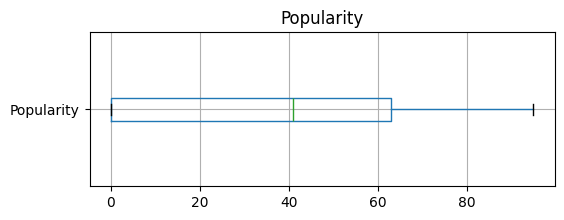

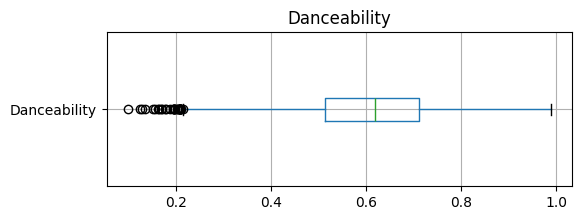

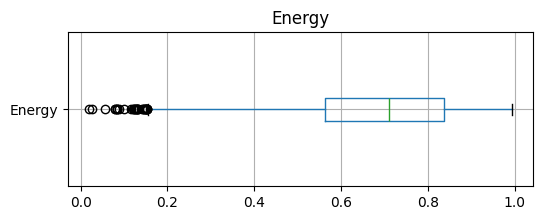

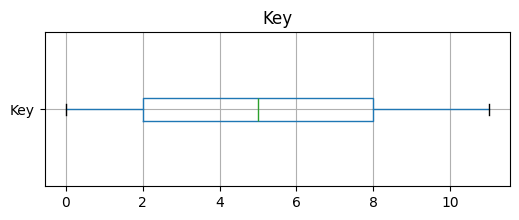

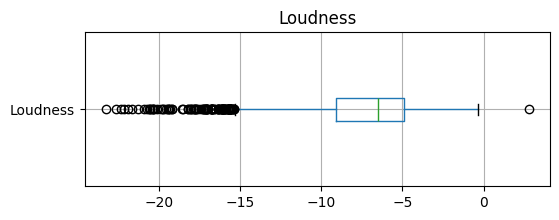

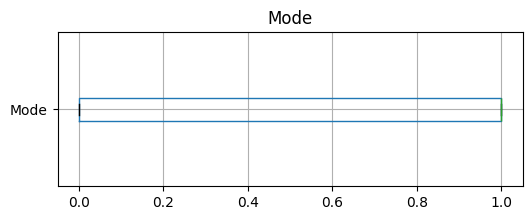

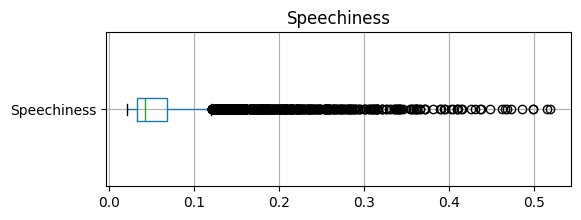

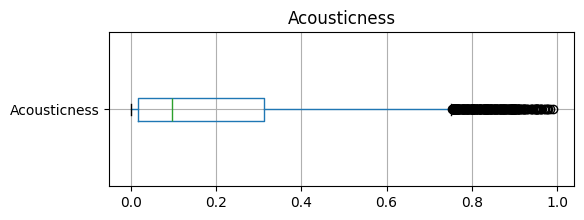

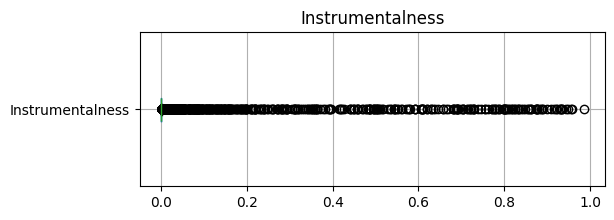

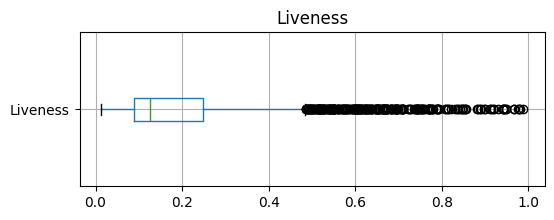

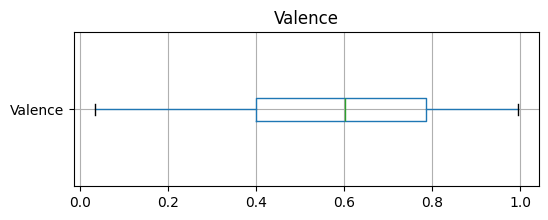

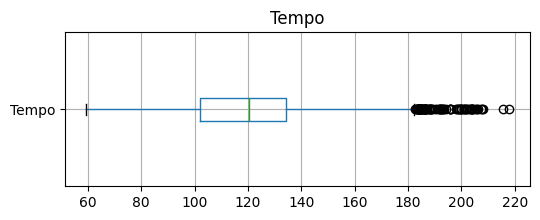

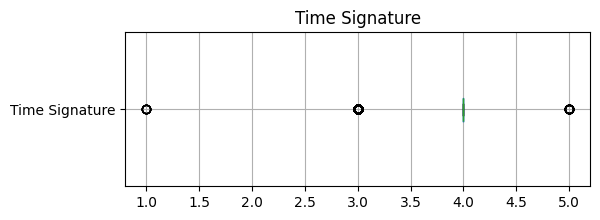

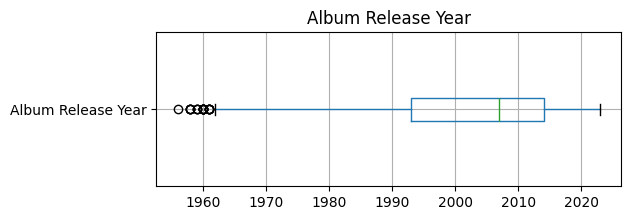

,Popularity,Danceability,Energy,Key,Loudness,Mode,Speechiness,Acousticness,Instrumentalness,Liveness,Valence,Tempo,Time Signature,Album Release Year,genre_0,genre_1,genre_2,genre_3,genre_4,genre_5,genre_6,genre_7,genre_8,genre_9
min,0,0.0994,0.0205,0.0,-23.242,0.0,0.0218,0.000003,0.000,0.012,0.0334,59.406,1.0,1956,0,0,0,0,0,0,0,0,0,0
max,95,0.9880,0.9940,11.0,2.769,1.0,0.5190,0.991000,0.985,0.989,0.9950,217.913,5.0,2023,1,1,1,1,1,1,1,1,1,1


In [264]:
for col in num_cols:
    plt.figure(figsize=(6, 2))
    df[[col]].boxplot(vert=False)
    plt.title(col)
    plt.show()

df.select_dtypes(include="number").agg(["min", "max"])

It doesn't seem like any of the values are impossible and/or dangerous for my recommendation system, so there will be no preprocessing for this one. Also, it should be noted that only Popularity, Loudness, Tempo, and Album Release Year will be scaled as the rest is already at a small range (0-10)

In [265]:
for col in num_cols:
    vals = df[col].dropna()

    Q1 = vals.quantile(0.25)
    Q3 = vals.quantile(0.75)
    IQR = Q3 - Q1

    LB = Q1 - 1.5 * IQR
    UB = Q3 + 1.5 * IQR

    outliers = vals[(vals < LB) | (vals > UB)]
    outlier_pct = (len(outliers) / len(vals)) * 100

    skewness = vals.skew()

    print(f"Column: {col}")
    print(f"  Outlier Percentage: {outlier_pct:.2f}%")
    print(f"  Skewness: {skewness:.3f}")
    print("-" * 40)


Column: Popularity
  Outlier Percentage: 0.00%
  Skewness: -0.040
----------------------------------------
Column: Danceability
  Outlier Percentage: 0.64%
  Skewness: -0.334
----------------------------------------
Column: Energy
  Outlier Percentage: 0.64%
  Skewness: -0.647
----------------------------------------
Column: Key
  Outlier Percentage: 0.00%
  Skewness: 0.028
----------------------------------------
Column: Loudness
  Outlier Percentage: 2.26%
  Skewness: -1.053
----------------------------------------
Column: Mode
  Outlier Percentage: 0.00%
  Skewness: -0.887
----------------------------------------
Column: Speechiness
  Outlier Percentage: 10.02%
  Skewness: 3.245
----------------------------------------
Column: Acousticness
  Outlier Percentage: 5.24%
  Skewness: 1.310
----------------------------------------
Column: Instrumentalness
  Outlier Percentage: 20.86%
  Skewness: 5.052
----------------------------------------
Column: Liveness
  Outlier Percentage: 5.02%
  

Using a thumb of rule that more than 5% outliers, skewness below -0.5, or skewness above 0.5 means the distribution is non-normal. Popularity and Tempo is normally distributed so it will later be scaled using standard scaler. Meanwhile, Loudness and Album Release Year are skewed as seen from its skewness below -0.5, hence it will be robust scaled later.

In [266]:
print("The percentage of missing values of each column:")
df.isna().mean()

The percentage of missing values of each column:


Track URI             0.000000
Track Name            0.000000
Artist Name(s)        0.000000
Album Name            0.000000
Popularity            0.000000
Artist Genres         0.000000
Danceability          0.000000
Energy                0.000000
Key                   0.000000
Loudness              0.000000
Mode                  0.000000
Speechiness           0.000000
Acousticness          0.030006
Instrumentalness      0.000000
Liveness              0.000000
Valence               0.000000
Tempo                 0.050010
Time Signature        0.000000
Album Release Year    0.000000
genre_0               0.000000
genre_1               0.000000
genre_2               0.000000
genre_3               0.000000
genre_4               0.000000
genre_5               0.000000
genre_6               0.000000
genre_7               0.000000
genre_8               0.000000
genre_9               0.000000
dtype: float64

I will firstly drop all rows that has more than 50% missing values. Furthermore, because there's no need for train-test split and no potential data leaks that could happen, I will impute the rest of the numerical columns using kNN imputer.

In [267]:
df = df.dropna(thresh=len(df.columns) * 0.5)

In [268]:
print("The percentage of missing values of each column:")
df.isna().mean()

The percentage of missing values of each column:


Track URI             0.000000
Track Name            0.000000
Artist Name(s)        0.000000
Album Name            0.000000
Popularity            0.000000
Artist Genres         0.000000
Danceability          0.000000
Energy                0.000000
Key                   0.000000
Loudness              0.000000
Mode                  0.000000
Speechiness           0.000000
Acousticness          0.030006
Instrumentalness      0.000000
Liveness              0.000000
Valence               0.000000
Tempo                 0.050010
Time Signature        0.000000
Album Release Year    0.000000
genre_0               0.000000
genre_1               0.000000
genre_2               0.000000
genre_3               0.000000
genre_4               0.000000
genre_5               0.000000
genre_6               0.000000
genre_7               0.000000
genre_8               0.000000
genre_9               0.000000
dtype: float64

It seems to have no effect to the missing values percentage at all which indicates that all rows has less than 50% missing values, making them all reliable enough to use for training the model.

In [269]:
from sklearn.impute import KNNImputer

imputer = KNNImputer(n_neighbors=5)
df[['Acousticness', 'Tempo']] = imputer.fit_transform(df[['Acousticness', 'Tempo']])

In [270]:
print("The percentage of missing values of each column:")
df.isna().mean()

The percentage of missing values of each column:


Track URI             0.0
Track Name            0.0
Artist Name(s)        0.0
Album Name            0.0
Popularity            0.0
Artist Genres         0.0
Danceability          0.0
Energy                0.0
Key                   0.0
Loudness              0.0
Mode                  0.0
Speechiness           0.0
Acousticness          0.0
Instrumentalness      0.0
Liveness              0.0
Valence               0.0
Tempo                 0.0
Time Signature        0.0
Album Release Year    0.0
genre_0               0.0
genre_1               0.0
genre_2               0.0
genre_3               0.0
genre_4               0.0
genre_5               0.0
genre_6               0.0
genre_7               0.0
genre_8               0.0
genre_9               0.0
dtype: float64

# Duplicates Check

In [271]:
print(f"Total Duplicates: {df.duplicated().sum()}")

Total Duplicates: 9


There are 9 duplicate songs, and we definitely don't want the users to be recommended the same song more than once, so I will drop all of them.

In [272]:
df = df.drop_duplicates()

In [273]:
print(f"Total Duplicates: {df.duplicated().sum()}")

Total Duplicates: 0


All duplicates have been dropped from the dataset.

# Correlation and Association Check

## Numerical x Numerical

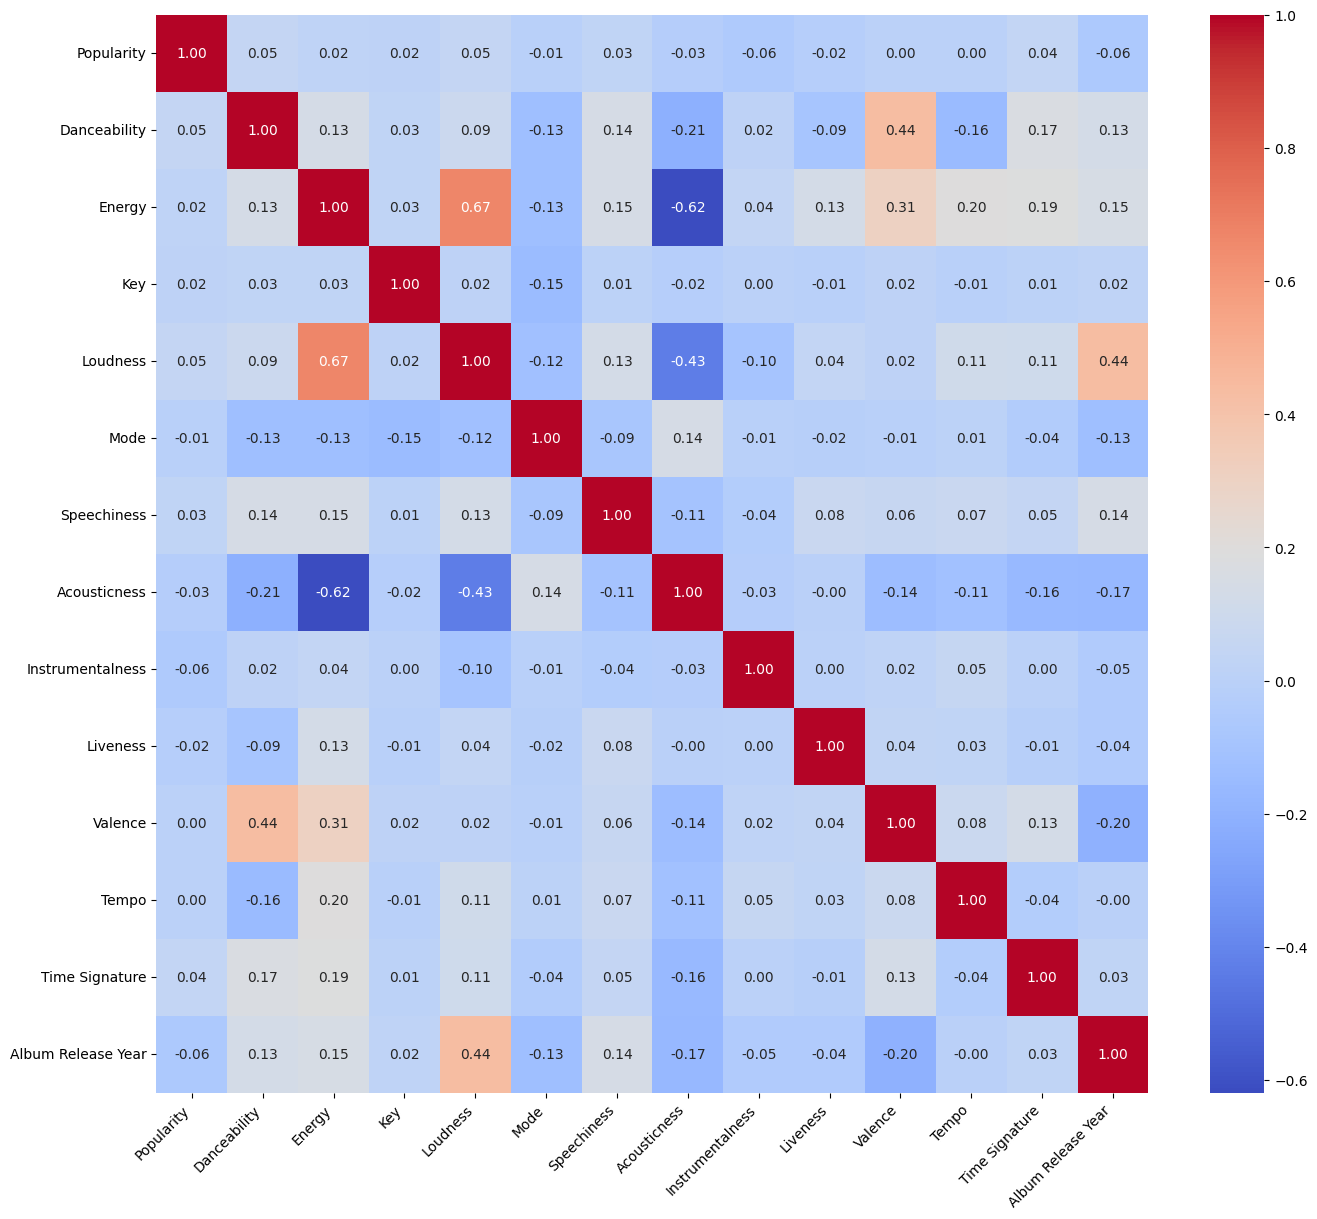

In [274]:
num_cols = ['Popularity', 'Danceability', 'Energy', 'Key', 'Loudness', 'Mode', 'Speechiness', 'Acousticness', 'Instrumentalness', 'Liveness', 'Valence', 'Tempo', 'Time Signature', 'Album Release Year']

plt.figure(figsize=(16,14))
sns.heatmap(df[num_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.show()

Using a table found from Research Gate (https://www.researchgate.net/figure/Interpretation-of-Correlation-Coefficient_tbl4_323336704), I will be interpreting some of the moderate to strong correlation which has more than or equal to 0.40:
- **Danceability x Valence** = 0.44 (Medium Positive Correlation). Tracks with higher danceability tend to exhibit higher valence, meaning they sound more cheerful and positive. This relationship is intuitive, as music designed for dancing often emphasizes upbeat rhythms and uplifting emotional tones. It suggests that rhythmic accessibility and emotional positivity commonly co-occur in popular music.
- **Energy x Acousticness** = -0.62 (Strong Negative Correlation). Higher-energy tracks are strongly associated with lower acousticness, indicating a shift toward electronically produced or amplified sounds. This reflects common production choices where energetic music relies on electric instrumentation, heavy processing, and synthetic elements rather than acoustic arrangements. The relationship highlights a clear stylistic divide between energetic and acoustic musical compositions.
- **Energy x Loudness** = 0.67 (Strong Positive Correlation). Tracks with higher energy levels tend to be louder, which aligns with the physical and perceptual nature of energy in music. Loudness enhances the intensity and impact of a track, making it feel more dynamic and powerful. This strong association suggests that loudness is a key contributor to how energy is perceived in audio features.
- **Loudness x Album Release Year** = 0.44 (Medium Positive Correlation). More recently released tracks tend to have higher loudness levels. This likely reflects the long-term evolution of music production practices, particularly the widespread use of dynamic range compression and loudness maximization in modern recordings. The relationship is consistent with how newer music is mastered to sound louder and more impactful, especially for digital and streaming platforms.
- **Loudness x Acousticness** = -0.43 (Medium Negative Correlation). Louder tracks are moderately associated with lower acousticness, implying that acoustic tracks are generally mixed at lower volumes compared to electronically produced music. This may be due to production norms where acoustic recordings preserve dynamic range, while non-acoustic tracks are often compressed to achieve higher loudness. The relationship reinforces the contrast between organic and heavily produced sound profiles.

## Categorical x Categorical

Since the only categorical column (other than identifiers) is Artist Genre, I won't be able to discover any intercategorical columns.

## Numerical x Categorical

The same goes to this type of association checking since the categories of a song has been abstractively divided into multiple label columns, I can't interpret them directly.

# Scaling

In [275]:
from sklearn.preprocessing import StandardScaler, RobustScaler

df[['Std_Popularity','Std_Tempo']] = StandardScaler().fit_transform(df[['Popularity','Tempo']])
df[['Rob_Loudness','Rob_Album Release Year']] = RobustScaler().fit_transform(df[['Loudness','Album Release Year']])

#### B. Create a content-based recommendation system, implemented as a function that takes a text input and returns five suggested items! 

In [276]:
X = df.drop(columns=['Track URI', 'Track Name', 'Artist Name(s)', 'Album Name', 'Artist Genres', 'Popularity','Tempo', 'Loudness','Album Release Year'])

from sklearn.metrics.pairwise import cosine_similarity

cosine_sim = cosine_similarity(X)

indices = pd.Series(df.index, index=df['Track Name'])

def get_recommendations(title, artist_name):
    idx = df.index[(df['Track Name'] == title) & (df['Artist Name(s)'] == artist_name)][0]
    top_similar = sorted(enumerate(cosine_sim[idx]), key=lambda x: x[1], reverse=True)[1:6]
    item_indices = [i for i, _ in top_similar]
    return df.loc[item_indices, ['Track Name', 'Artist Name(s)', 'Album Name', 'Artist Genres', 'Album Release Year', 'Popularity', 'Danceability', 'Energy', 'Key', 'Loudness', 'Mode', 'Speechiness', 'Acousticness', 'Instrumentalness', 'Liveness', 'Valence', 'Tempo', 'Time Signature']]

#### C. Provide a minimum of three inputs to the function and examine if the recommendations correspond to each input!

In [277]:
pd.set_option('display.max_colwidth', None)

In [278]:
get_recommendations('Hopelessly Devoted To You - From "Grease" Original Motion Picture Soundtrack', 'Olivia Newton-John')

,Track Name,Artist Name(s),Album Name,Artist Genres,Album Release Year,Popularity,Danceability,Energy,Key,Loudness,Mode,Speechiness,Acousticness,Instrumentalness,Liveness,Valence,Tempo,Time Signature
3590,"Twist, Twist Senora",Gary U.S. Bonds,The Very Best Of Gary U.S. Bonds (The Original Legrand Masters),"doo-wop,rhythm and blues",1998,0,0.504,0.815,10.0,-7.649,1.0,0.0576,0.65700,0.009700,0.8530,0.877,186.680,4.0
4910,Catch,Kosheen,Resist,"electronica,trip hop",2001,0,0.655,0.941,10.0,-4.577,0.0,0.0473,0.00264,0.000018,0.3840,0.752,130.003,4.0
4283,The Distance,CAKE,Fashion Nugget,"alternative rock,pop rock,post-grunge,sacramento indie",1996,64,0.456,0.752,11.0,-8.121,0.0,0.0900,0.00950,0.001450,0.0573,0.897,183.569,4.0
895,Sway,Bic Runga,Drive,"classic nz pop,lilith,new wave pop,nz pop,nz singer-songwriter",1997,60,0.565,0.429,9.0,-9.196,1.0,0.0261,0.15700,0.000000,0.1300,0.266,95.701,4.0
4337,Elevator (feat. Timbaland),"Flo Rida, Timbaland",Mail on Sunday,"dance pop,miami hip hop,pop,pop rap,dance pop,pop,pop rap",2008,54,0.812,0.874,6.0,-6.015,0.0,0.0905,0.10900,0.000025,0.2140,0.470,120.025,4.0


In [284]:
df.loc[(df['Track Name'] == 'Hopelessly Devoted To You - From "Grease" Original Motion Picture Soundtrack') & (df['Artist Name(s)'] == 'Olivia Newton-John')]

,Track URI,Track Name,Artist Name(s),Album Name,Popularity,Artist Genres,Danceability,Energy,Key,Loudness,Mode,Speechiness,Acousticness,Instrumentalness,Liveness,Valence,Tempo,Time Signature,Album Release Year,genre_0,genre_1,genre_2,genre_3,genre_4,genre_5,genre_6,genre_7,genre_8,genre_9,Std_Popularity,Std_Tempo,Rob_Loudness,Rob_Album Release Year
3502,spotify:track:6Ehu8vSEK1aaHbDn8TMTED,"Hopelessly Devoted To You - From ""Grease"" Original Motion Picture Soundtrack",Olivia Newton-John,Grease (Limited Edition),0,"adult standards,australian dance,disco,mellow gold,soft rock",0.276,0.344,9.0,-13.115,1.0,0.0378,0.332,0.029,0.126,0.346,73.805,4.0,1998,0,0,1,1,1,1,1,1,1,1,-1.26401,-1.836606,-1.586252,-0.428571


In [279]:
get_recommendations("Mama's Little Girl", "Linda George")

,Track Name,Artist Name(s),Album Name,Artist Genres,Album Release Year,Popularity,Danceability,Energy,Key,Loudness,Mode,Speechiness,Acousticness,Instrumentalness,Liveness,Valence,Tempo,Time Signature
544,3 Words,"Cheryl, will.i.am",3 Words,"dance pop,post-teen pop,talent show,dance pop,pop",2009,43,0.750,0.580,9.0,-7.505,1.0,0.0319,0.71300,0.003180,0.0986,0.510,130.024,4.0
992,I Was Made For Lovin' You,KISS,Dynasty,"glam rock,hard rock,rock",1979,84,0.768,0.852,4.0,-6.215,1.0,0.0380,0.21400,0.000074,0.0723,0.867,128.373,4.0
2674,Ray of Light,Madonna,Ray of Light,"dance pop,pop",1998,63,0.561,0.909,3.0,-7.878,1.0,0.0312,0.00118,0.460000,0.0713,0.710,127.172,4.0
1453,Always,"Waze & Odyssey, George Michael, Mary J. Blige, Tommy Theo",Always,"house,uk house,new wave pop,dance pop,neo soul,r&b,urban contemporary",2020,54,0.700,0.914,8.0,-6.430,0.0,0.1060,0.01090,0.002960,0.0849,0.913,125.070,4.0
1279,Hot In Herre,Nelly,Nellyville (Explicit Version),"dance pop,gangster rap,hip hop,pop rap,rap,st louis rap,urban contemporary",2002,0,0.955,0.728,9.0,-4.862,0.0,0.1220,0.21900,0.000000,0.0612,0.922,107.082,4.0


In [283]:
df.loc[(df['Track Name'] == "Mama's Little Girl") & (df['Artist Name(s)'] == "Linda George")]

,Track URI,Track Name,Artist Name(s),Album Name,Popularity,Artist Genres,Danceability,Energy,Key,Loudness,Mode,Speechiness,Acousticness,Instrumentalness,Liveness,Valence,Tempo,Time Signature,Album Release Year,genre_0,genre_1,genre_2,genre_3,genre_4,genre_5,genre_6,genre_7,genre_8,genre_9,Std_Popularity,Std_Tempo,Rob_Loudness,Rob_Album Release Year
4731,spotify:track:4BKB9YW3ymCode03eAG9iY,Mama's Little Girl,Linda George,Miss Linda George,0,No Genre,0.388,0.738,5.0,-11.933,0.0,0.296,0.165,0.000942,0.0724,0.578,173.542,4.0,1974,1,0,1,1,1,0,0,1,1,0,-1.26401,2.025824,-1.303155,-1.571429


In [280]:
get_recommendations('All For Love - From "The Three Musketeers" Soundtrack', "Bryan Adams, Sting, Rod Stewart")

,Track Name,Artist Name(s),Album Name,Artist Genres,Album Release Year,Popularity,Danceability,Energy,Key,Loudness,Mode,Speechiness,Acousticness,Instrumentalness,Liveness,Valence,Tempo,Time Signature
926,Stomp! - Single Version,The Brothers Johnson,Strawberry Letter 23: The Very Best Of The Brothers Johnson,"disco,funk,jazz funk,p funk,post-disco,quiet storm,soul",2003,64,0.859,0.782,10.0,-8.344,1.0,0.0369,0.1540,0.029700,0.0693,0.931,100.8276,4.0
4619,Bring It All Back,S Club,S Club,No Genre,1999,64,0.679,0.903,4.0,-4.914,1.0,0.0463,0.3330,0.000000,0.3720,0.872,108.1140,4.0
3931,Let It Go - DJ Boat Remix,"Josefine, DJ Boat",Let It Go (DJ Boat Remix),"scandipop,ghanaian alternative",2021,26,0.753,0.649,3.0,-7.731,0.0,0.0357,0.0583,0.006190,0.1470,0.493,112.0260,4.0
2802,Starships,Nicki Minaj,Pink Friday ... Roman Reloaded (Deluxe),"hip pop,pop,queens hip hop,rap",2012,64,0.747,0.716,11.0,-2.457,0.0,0.0751,0.1350,0.000000,0.2510,0.751,125.0060,4.0
697,The Trouble with Us,"Marcus Marr, Nick Murphy",The Trouble with Us,"uk alternative pop,australian electropop,downtempo,indietronica",2015,0,0.828,0.735,2.0,-4.929,1.0,0.0636,0.3230,0.000893,0.1590,0.835,100.0174,4.0


In [ ]:
df.loc[(df['Track Name'] == 'All For Love - From "The Three Musketeers" Soundtrack') & (df['Artist Name(s)'] == 'Bryan Adams, Sting, Rod Stewart')]

,Track URI,Track Name,Artist Name(s),Album Name,Popularity,Artist Genres,Danceability,Energy,Key,Loudness,Mode,Speechiness,Acousticness,Instrumentalness,Liveness,Valence,Tempo,Time Signature,Album Release Year,genre_0,genre_1,genre_2,genre_3,genre_4,genre_5,genre_6,genre_7,genre_8,genre_9,Std_Popularity,Std_Tempo,Rob_Loudness,Rob_Album Release Year
341,spotify:track:7a8tyR4KZCq7BWUXcxIB7p,"All For Love - From ""The Three Musketeers"" Soundtrack","Bryan Adams, Sting, Rod Stewart",The Best Of Me,0,"canadian pop,canadian singer-songwriter,classic canadian rock,heartland rock,mellow gold,soft rock,permanent wave,soft rock,sophisti-pop,mellow gold,soft rock",0.506,0.573,2.0,-6.56,1.0,0.0282,0.185,0.0,0.119,0.0958,74.806,4.0,1999,0,1,1,1,1,1,1,1,1,1,-1.26401,-1.797841,-0.016286,-0.380952


#### D. Produce a concise presentation video covering your analysis highlights! 

Video Link: https://youtu.be/J5F9GduuAkw